# Trustworthiness Evaluation

## 1. Research Objective

This notebook is now an artifact-only trustworthiness analysis. It does **not** train, refit, load checkpoints, or rerun any forecasting model. All authoritative model forecasts are loaded from `../results/validated_forecasts.csv`.

The goal is to evaluate point accuracy, robustness, temporal generalisation, uncertainty calibration, explainability, and overall trustworthiness using saved forecast vectors and reproducible deterministic baselines only.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape, mase

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.6f}".format)

ARTIFACT_ONLY = True
MODEL_FITTING_EXECUTED = False
MODEL_CHECKPOINT_LOADED = False
FORECAST_VECTOR_REGENERATED = False


## 2. Load Authoritative Forecast Artifact

Expected artifact: `../results/validated_forecasts.csv`

Required columns:
- `Timestamp`
- `Actual`
- `Naive`
- `Persistence_Enhanced_LSTM`
- `Chronos_Bolt_Tiny`
- `TimesFM`
- `ARIMA_Rolling`
- `Prophet_Periodic_Refit`
- `Simple_Exp_Smoothing`
- `Holt_Winters`


In [2]:
forecast_artifact_path = PROJECT_ROOT / "results" / "validated_forecasts.csv"
forecast_results = pd.read_csv(forecast_artifact_path, parse_dates=["Timestamp"])

expected_columns = [
    "Timestamp",
    "Actual",
    "Naive",
    "Persistence_Enhanced_LSTM",
    "Chronos_Bolt_Tiny",
    "TimesFM",
    "ARIMA_Rolling",
    "Prophet_Periodic_Refit",
    "Simple_Exp_Smoothing",
    "Holt_Winters",
]

missing_columns = [column for column in expected_columns if column not in forecast_results.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

forecast_results = forecast_results[expected_columns].sort_values("Timestamp").reset_index(drop=True)
forecast_results["Timestamp"] = pd.to_datetime(forecast_results["Timestamp"], utc=True)
forecast_results = forecast_results.set_index("Timestamp")

value_columns = expected_columns[1:]

artifact_validation = pd.DataFrame(
    [
        {"Check": "Shape is (1061, 10) before Timestamp index", "Result": tuple(pd.read_csv(forecast_artifact_path).shape) == (1061, 10)},
        {"Check": "Timestamp unique", "Result": forecast_results.index.is_unique},
        {"Check": "Timestamp sorted", "Result": forecast_results.index.is_monotonic_increasing},
        {"Check": "No missing values", "Result": not forecast_results[value_columns].isna().any().any()},
        {"Check": "All forecast values finite", "Result": bool(np.isfinite(forecast_results[value_columns].to_numpy(dtype=float)).all())},
        {"Check": "Exact test start date", "Result": forecast_results.index.min() == pd.Timestamp("2023-08-12", tz="UTC")},
        {"Check": "Exact test end date", "Result": forecast_results.index.max() == pd.Timestamp("2026-07-07", tz="UTC")},
        {"Check": "Test length is 1061", "Result": len(forecast_results) == 1061},
    ]
)

model_vector_frame = forecast_results.drop(columns=["Actual"])
duplicate_vector_rows = []
for left_position, left_name in enumerate(model_vector_frame.columns):
    for right_name in model_vector_frame.columns[left_position + 1:]:
        duplicate_vector_rows.append(
            {
                "Pair": f"{left_name} vs {right_name}",
                "Duplicated Vector": bool(model_vector_frame[left_name].equals(model_vector_frame[right_name])),
            }
        )
duplicate_vector_check = pd.DataFrame(duplicate_vector_rows)
artifact_validation.loc[len(artifact_validation)] = {
    "Check": "No duplicated forecast vectors",
    "Result": not duplicate_vector_check["Duplicated Vector"].any(),
}

display(artifact_validation)
duplicate_vector_check


,Check,Result
0,"Shape is (1061, 10) before Timestamp index",True
1,Timestamp unique,True
2,Timestamp sorted,True
3,No missing values,True
4,All forecast values finite,True
5,Exact test start date,True
6,Exact test end date,True
7,Test length is 1061,True
8,No duplicated forecast vectors,True


,Pair,Duplicated Vector
0,Naive vs Persistence_Enhanced_LSTM,False
1,Naive vs Chronos_Bolt_Tiny,False
2,Naive vs TimesFM,False
3,Naive vs ARIMA_Rolling,False
4,Naive vs Prophet_Periodic_Refit,False
5,Naive vs Simple_Exp_Smoothing,False
6,Naive vs Holt_Winters,False
7,Persistence_Enhanced_LSTM vs Chronos_Bolt_Tiny,False
8,Persistence_Enhanced_LSTM vs TimesFM,False
9,Persistence_Enhanced_LSTM vs ARIMA_Rolling,False


## 3. Load Dataset And Verify Split

In [3]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"
raw_df = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(raw_df)
target = df_daily["Close"].dropna().astype(float).rename("Close")

split_idx = int(len(target) * 0.8)
train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = forecast_results["Actual"].rename("Actual")

split_validation = pd.DataFrame(
    [
        {"Check": "Train ends 2023-08-11", "Result": train.index.max() == pd.Timestamp("2023-08-11", tz="UTC")},
        {"Check": "Test begins 2023-08-12", "Result": test.index.min() == pd.Timestamp("2023-08-12", tz="UTC")},
        {"Check": "Test length is 1061", "Result": len(test) == 1061},
        {"Check": "Artifact index equals reconstructed test index", "Result": forecast_results.index.equals(test.index)},
        {"Check": "Artifact Actual equals reconstructed Close", "Result": np.allclose(forecast_results["Actual"], test.to_numpy(dtype=float))},
    ]
)
split_validation


,Check,Result
0,Train ends 2023-08-11,True
1,Test begins 2023-08-12,True
2,Test length is 1061,True
3,Artifact index equals reconstructed test index,True
4,Artifact Actual equals reconstructed Close,True


## 4. Forecast Protocol Comparability

The main Trust Score ranking includes models with exact saved vectors or deterministic no-leakage baselines. ARIMA, Simple Exponential Smoothing, and additive-trend non-seasonal Holt-Winters are true rolling one-step evaluations with 128-day contexts; Prophet is explicitly labelled as a 30-day periodic-refit protocol. SARIMA is omitted because no weekly seasonality was supported and its zero-seasonal form would duplicate ARIMA.


In [4]:
available_result_files = {path.name for path in (PROJECT_ROOT / "results").glob("*")}
original_lstm_vector_exists = "original_lstm_forecast.csv" in available_result_files or "Original_LSTM" in forecast_results.columns
arima_rolling_vector_exists = "arima_rolling_forecast.csv" in available_result_files or "ARIMA_Rolling" in forecast_results.columns
sarima_rolling_vector_exists = "sarima_rolling_forecast.csv" in available_result_files or "SARIMA_Rolling" in forecast_results.columns
simple_exp_smoothing_vector_exists = "simple_exp_smoothing_forecast.csv" in available_result_files and "Simple_Exp_Smoothing" in forecast_results.columns
holt_winters_vector_exists = "holt_winters_forecast.csv" in available_result_files and "Holt_Winters" in forecast_results.columns
prophet_rolling_vector_exists = "prophet_rolling_forecast.csv" in available_result_files and "Prophet_Periodic_Refit" in forecast_results.columns

protocol_comparability = pd.DataFrame(
    [
        {"Model": "Naive", "Model Type": "Classical baseline", "Protocol": "Rolling one-step", "Saved Vector": True, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "7-Day Moving Average", "Model Type": "Classical baseline", "Protocol": "Deterministic rolling one-step", "Saved Vector": False, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "Persistence-Enhanced LSTM", "Model Type": "Supervised deep learning", "Protocol": "Rolling one-step", "Saved Vector": True, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "TimesFM", "Model Type": "Zero-shot time-series foundation model", "Protocol": "Rolling one-step", "Saved Vector": True, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "Chronos-Bolt-Tiny", "Model Type": "Zero-shot time-series foundation model", "Protocol": "Rolling one-step", "Saved Vector": True, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes"},
        {"Model": "Original LSTM", "Model Type": "Supervised deep learning", "Protocol": "Exploratory historical workflow", "Saved Vector": original_lstm_vector_exists, "Uses newly observed test actuals": np.nan, "Eligible for main Trust Score": "Yes" if original_lstm_vector_exists else "No"},
        {"Model": "ARIMA Rolling One-Step", "Model Type": "Statistical model", "Protocol": "Rolling one-step with state append", "Saved Vector": arima_rolling_vector_exists, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes" if arima_rolling_vector_exists else "No"},
        {"Model": "SARIMA", "Model Type": "Statistical model", "Protocol": "Static multi-step unless saved rolling vector exists", "Saved Vector": sarima_rolling_vector_exists, "Uses newly observed test actuals": False, "Eligible for main Trust Score": "Yes" if sarima_rolling_vector_exists else "No"},
        {"Model": "Simple Exponential Smoothing Rolling One-Step", "Model Type": "Statistical model", "Protocol": "Daily refit on strict 128-day history", "Saved Vector": simple_exp_smoothing_vector_exists, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes" if simple_exp_smoothing_vector_exists else "No"},
        {"Model": "Holt-Winters Rolling One-Step", "Model Type": "Statistical model", "Protocol": "Daily additive-trend refit on strict 128-day history; no seasonality", "Saved Vector": holt_winters_vector_exists, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes" if holt_winters_vector_exists else "No"},
        {"Model": "Prophet 30-Day Periodic Refit", "Model Type": "Additive statistical model", "Protocol": "30-day periodic refit with strict 128-day history", "Saved Vector": prophet_rolling_vector_exists, "Uses newly observed test actuals": True, "Eligible for main Trust Score": "Yes" if prophet_rolling_vector_exists else "No"},
    ]
).set_index("Model")
protocol_comparability


,Model Type,Protocol,Saved Vector,Uses newly observed test actuals,Eligible for main Trust Score
Model,,,,,
Naive,Classical baseline,Rolling one-step,True,True,Yes
7-Day Moving Average,Classical baseline,Deterministic rolling one-step,False,True,Yes
Persistence-Enhanced LSTM,Supervised deep learning,Rolling one-step,True,True,Yes
TimesFM,Zero-shot time-series foundation model,Rolling one-step,True,True,Yes
Chronos-Bolt-Tiny,Zero-shot time-series foundation model,Rolling one-step,True,True,Yes
Original LSTM,Supervised deep learning,Exploratory historical workflow,False,NaN,No
ARIMA Rolling One-Step,Statistical model,Rolling one-step with state append,True,True,Yes
SARIMA,Statistical model,Static multi-step unless saved rolling vector ...,False,False,No
Simple Exponential Smoothing Rolling One-Step,Statistical model,Daily refit on strict 128-day history,True,True,Yes


## 5. Accuracy Evaluation

In [5]:
forecast_series = {
    "Naive": forecast_results["Naive"].rename("Naive"),
    "Persistence-Enhanced LSTM": forecast_results["Persistence_Enhanced_LSTM"].rename("Persistence-Enhanced LSTM"),
    "TimesFM": forecast_results["TimesFM"].rename("TimesFM"),
    "Chronos-Bolt-Tiny": forecast_results["Chronos_Bolt_Tiny"].rename("Chronos-Bolt-Tiny"),
    "ARIMA Rolling One-Step": forecast_results["ARIMA_Rolling"].rename("ARIMA Rolling One-Step"),
    "Prophet 30-Day Periodic Refit": forecast_results["Prophet_Periodic_Refit"].rename("Prophet 30-Day Periodic Refit"),
    "Simple Exponential Smoothing Rolling One-Step": forecast_results["Simple_Exp_Smoothing"].rename("Simple Exponential Smoothing Rolling One-Step"),
    "Holt-Winters Rolling One-Step": forecast_results["Holt_Winters"].rename("Holt-Winters Rolling One-Step"),
}

# Deterministic no-leakage 7-day moving average: prediction at t uses t-7 through t-1 only.
moving_average_7 = target.shift(1).rolling(window=7).mean().reindex(test.index).rename("7-Day Moving Average")
assert moving_average_7.index.equals(y_test.index)
assert not moving_average_7.isna().any()

ma7_audit = pd.DataFrame(
    {
        "forecast_date": test.index[:10],
        "window_start": [target.loc[:date].iloc[:-1].tail(7).index.min() for date in test.index[:10]],
        "window_end": [target.loc[:date].iloc[:-1].tail(7).index.max() for date in test.index[:10]],
        "forecast": moving_average_7.iloc[:10].to_numpy(dtype=float),
        "actual": y_test.iloc[:10].to_numpy(dtype=float),
    }
)
assert (pd.to_datetime(ma7_audit["window_end"]) < pd.to_datetime(ma7_audit["forecast_date"])).all()
forecast_series["7-Day Moving Average"] = moving_average_7

if original_lstm_vector_exists:
    if "Original_LSTM" in forecast_results.columns:
        forecast_series["Original LSTM"] = forecast_results["Original_LSTM"].rename("Original LSTM")
    else:
        original_lstm_path = PROJECT_ROOT / "results" / "original_lstm_forecast.csv"
        original_lstm_df = pd.read_csv(original_lstm_path, parse_dates=["Timestamp"]).set_index("Timestamp")
        if original_lstm_df.index.tz is None:
            original_lstm_df.index = original_lstm_df.index.tz_localize("UTC")
        forecast_series["Original LSTM"] = original_lstm_df.iloc[:, 0].reindex(y_test.index).rename("Original LSTM")

metrics_rows = []
for model_name, forecast in forecast_series.items():
    metrics_rows.append(
        {
            "Model": model_name,
            "MAE": mae(y_test, forecast),
            "RMSE": rmse(y_test, forecast),
            "MAPE": mape(y_test, forecast),
            "sMAPE": smape(y_test, forecast),
            "MASE": mase(y_test, forecast, train, seasonal_period=1),
            "N": len(pd.concat([y_test, forecast], axis=1).dropna()),
        }
    )

metrics_table = pd.DataFrame(metrics_rows).set_index("Model")
metrics_table["Relative MAE"] = metrics_table["MAE"] / metrics_table.loc["Naive", "MAE"]
metrics_table.sort_values("RMSE")


,MAE,RMSE,MAPE,sMAPE,MASE,N,Relative MAE
Model,,,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,4.575633,1061,1.000000
Simple Exponential Smoothing Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871,4.575652,1061,1.000004
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209,4.609396,1061,1.007379
Holt-Winters Rolling One-Step,1308.541314,1871.702185,1.763640,1.763424,4.640128,1061,1.014095
Persistence-Enhanced LSTM,1321.365311,1881.091190,1.783956,1.791645,4.685603,1061,1.024034
TimesFM,1349.946786,1924.199337,1.823179,1.823895,4.786953,1061,1.046184
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,5.049640,1061,1.103594
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,7.835935,1061,1.712536
Prophet 30-Day Periodic Refit,8195.262862,10781.162873,11.199767,11.287185,29.060658,1061,6.351178


## 6. Robustness Evaluation

In [6]:
returns = y_test.pct_change()
rolling_volatility = returns.rolling(window=14, min_periods=7).std()
low_threshold = rolling_volatility.quantile(0.33)
high_threshold = rolling_volatility.quantile(0.67)
up_threshold = returns.quantile(0.80)
down_threshold = returns.quantile(0.20)

regime_masks = {
    "Low Volatility": rolling_volatility <= low_threshold,
    "High Volatility": rolling_volatility >= high_threshold,
    "Major Upward Movement": returns >= up_threshold,
    "Major Downward Movement": returns <= down_threshold,
}

regime_rows = []
for regime_name, mask in regime_masks.items():
    regime_index = mask[mask].index
    for model_name, forecast in forecast_series.items():
        regime_rows.append(
            {
                "Regime": regime_name,
                "Model": model_name,
                "MAE": mae(y_test.reindex(regime_index), forecast.reindex(regime_index)),
                "RMSE": rmse(y_test.reindex(regime_index), forecast.reindex(regime_index)),
                "MAPE": mape(y_test.reindex(regime_index), forecast.reindex(regime_index)),
                "sMAPE": smape(y_test.reindex(regime_index), forecast.reindex(regime_index)),
                "MASE": mase(y_test.reindex(regime_index), forecast.reindex(regime_index), train, seasonal_period=1),
                "N": len(regime_index),
            }
        )

regime_performance = pd.DataFrame(regime_rows).set_index(["Regime", "Model"]).sort_index()
regime_performance


MAE  \
Regime                  Model                                                       
High Volatility         7-Day Moving Average                          2682.163896   
                        ARIMA Rolling One-Step                        1686.852502   
                        Chronos-Bolt-Tiny                             1864.388500   
                        Holt-Winters Rolling One-Step                 1702.078133   
                        Naive                                         1693.012098   
                        Persistence-Enhanced LSTM                     1724.570417   
                        Prophet 30-Day Periodic Refit                 9223.351081   
                        Simple Exponential Smoothing Rolling One-Step 1677.361408   
                        TimesFM                                       1725.906316   
Low Volatility          7-Day Moving Average                          1687.232225   
                        ARIMA Rolling One-Step                         974.788478   
                        Chronos-Bolt-Tiny                             1083.427281   
                        Holt-Winters Rolling One-Step                  976.591557   
                        Naive                                          945.739741   
                        Persistence-Enhanced LSTM                      987.706808   
                        Prophet 30-Day Periodic Refit                 7189.626919   
                        Simple Exponential Smoothing Rolling One-Step  954.090166   
                        TimesFM                                       1004.046175   
Major Downward Movement 7-Day Moving Average                          2963.258605   
                        ARIMA Rolling One-Step                        2441.424483   
                        Chronos-Bolt-Tiny                             2676.764417   
                        Holt-Winters Rolling One-Step                 2445.651946   
                        Naive                                         2405.814387   
                        Persistence-Enhanced LSTM                     2117.089426   
                        Prophet 30-Day Periodic Refit                 9036.748936   
                        Simple Exponential Smoothing Rolling One-Step 2399.264340   
                        TimesFM                                       2454.908958   
Major Upward Movement   7-Day Moving Average                          2869.267655   
                        ARIMA Rolling One-Step                        2421.497518   
                        Chronos-Bolt-Tiny                             2259.397087   
                        Holt-Winters Rolling One-Step                 2409.613118   
                        Naive                                         2470.870708   
                        Persistence-Enhanced LSTM                     2722.286263   
                        Prophet 30-Day Periodic Refit                 7904.968508   
                        Simple Exponential Smoothing Rolling One-Step 2466.696936   
                        TimesFM                                       2467.687670   

                                                                              RMSE  \
Regime                  Model                                                        
High Volatility         7-Day Moving Average                           3614.703600   
                        ARIMA Rolling One-Step                         2377.002047   
                        Chronos-Bolt-Tiny                              2557.524924   
                        Holt-Winters Rolling One-Step                  2401.125345   
                        Naive                                          2377.559838   
                        Persistence-Enhanced LSTM                      2418.830160   
                        Prophet 30-Day Periodic Refit                 11946.471298   
                        Simple Exponential Smoothing Rolling One-Step  23

## 7. Generalisation Evaluation

In [7]:
segment_rows = []
for segment_name, segment_index in zip(
    ["Earlier Test Period", "Middle Test Period", "Later Test Period"],
    np.array_split(y_test.index, 3),
):
    for model_name, forecast in forecast_series.items():
        segment_rows.append(
            {
                "Segment": segment_name,
                "Model": model_name,
                "MAE": mae(y_test.reindex(segment_index), forecast.reindex(segment_index)),
                "RMSE": rmse(y_test.reindex(segment_index), forecast.reindex(segment_index)),
                "MAPE": mape(y_test.reindex(segment_index), forecast.reindex(segment_index)),
                "sMAPE": smape(y_test.reindex(segment_index), forecast.reindex(segment_index)),
                "MASE": mase(y_test.reindex(segment_index), forecast.reindex(segment_index), train, seasonal_period=1),
                "N": len(segment_index),
            }
        )

segment_generalisation = pd.DataFrame(segment_rows).set_index(["Segment", "Model"]).sort_index()
segment_generalisation


MAE  \
Segment             Model                                                        
Earlier Test Period 7-Day Moving Average                           1613.532284   
                    ARIMA Rolling One-Step                          923.016405   
                    Chronos-Bolt-Tiny                              1033.215942   
                    Holt-Winters Rolling One-Step                   944.946686   
                    Naive                                           936.257062   
                    Persistence-Enhanced LSTM                       960.545953   
                    Prophet 30-Day Periodic Refit                  6170.482235   
                    Simple Exponential Smoothing Rolling One-Step   931.346495   
                    TimesFM                                         959.797107   
Later Test Period   7-Day Moving Average                           2421.860579   
                    ARIMA Rolling One-Step                         1430.023403   
                    Chronos-Bolt-Tiny                              1569.593481   
                    Holt-Winters Rolling One-Step                  1418.532857   
                    Naive                                          1401.305354   
                    Persistence-Enhanced LSTM                      1427.699636   
                    Prophet 30-Day Periodic Refit                 10116.656175   
                    Simple Exponential Smoothing Rolling One-Step  1406.266984   
                    TimesFM                                        1466.605426   
Middle Test Period  7-Day Moving Average                           2594.534705   
                    ARIMA Rolling One-Step                         1546.951757   
                    Chronos-Bolt-Tiny                              1669.679268   
                    Holt-Winters Rolling One-Step                  1562.455108   
                    Naive                                          1533.810734   
                    Persistence-Enhanced LSTM                      1576.150722   
                    Prophet 30-Day Periodic Refit                  8304.077841   
                    Simple Exponential Smoothing Rolling One-Step  1533.789997   
                    TimesFM                                        1623.767368   

                                                                          RMSE  \
Segment             Model                                                        
Earlier Test Period 7-Day Moving Average                           2246.462544   
                    ARIMA Rolling One-Step                         1402.661622   
                    Chronos-Bolt-Tiny                              1531.946847   
                    Holt-Winters Rolling One-Step                  1428.902880   
                    Naive                                          1408.715265   
                    Persistence-Enhanced LSTM                      1429.052390   
                    Prophet 30-Day Periodic Refit                  8067.194792   
                    Simple Exponential Smoothing Rolling One-Step  1410.171763   
                    TimesFM                                        1447.154027   
Later Test Period   7-Day Moving Average                           3228.992440   
                    ARIMA Rolling One-Step                         1964.653266   
                    Chronos-Bolt-Tiny                              2128.869810   
                    Holt-Winters Rolling One-Step                  1945.715710   
                    Naive                                          1931.860167   
                    Persistence-Enhanced LSTM                      1948.165364   
                    Prophet 30-Day Periodic Refit                 12653.359424   
                    Simple Exponential Smoothing Rolling One-Step  1937.529135   
                    TimesFM                                        2019.309963   
Middle Test Period  7-Day Moving Average                

## 8. Uncertainty Evaluation

Foundation-model uncertainty reports validated native intervals alongside training-only conformalized intervals using the final 180 training days. ARIMA, Simple Exponential Smoothing, Holt-Winters, Naive, and the 7-Day Moving Average receive validation-residual empirical intervals from the final 1,061 training days. The two new smoothing models use saved validation vectors generated under their identical true rolling one-step protocols.

No test residuals are used to force coverage. Persistence-Enhanced LSTM has no saved validation uncertainty artifact, so it receives an explicit uncertainty penalty rather than invented intervals.


In [8]:
validation_window = train.iloc[-len(test):]
validation_actual = validation_window.rename("actual")
validation_index = validation_actual.index
arima_validation = pd.read_csv(
    PROJECT_ROOT / "results" / "arima_validation_forecast.csv", parse_dates=["Timestamp"]
).set_index("Timestamp")["ARIMA_Rolling_Validation"]
arima_validation.index = pd.to_datetime(arima_validation.index, utc=True)
simple_exp_smoothing_validation = pd.read_csv(PROJECT_ROOT / "results" / "simple_exp_smoothing_validation_forecast.csv", parse_dates=["Timestamp"]).set_index("Timestamp")["Simple_Exp_Smoothing_Validation"]
holt_winters_validation = pd.read_csv(PROJECT_ROOT / "results" / "holt_winters_validation_forecast.csv", parse_dates=["Timestamp"]).set_index("Timestamp")["Holt_Winters_Validation"]
simple_exp_smoothing_validation.index = pd.to_datetime(simple_exp_smoothing_validation.index, utc=True)
holt_winters_validation.index = pd.to_datetime(holt_winters_validation.index, utc=True)
arima_validation = arima_validation.reindex(validation_index)
assert arima_validation.index.equals(validation_index) and not arima_validation.isna().any()
simple_exp_smoothing_validation = simple_exp_smoothing_validation.reindex(validation_index)
holt_winters_validation = holt_winters_validation.reindex(validation_index)
assert simple_exp_smoothing_validation.index.equals(validation_index) and not simple_exp_smoothing_validation.isna().any()
assert holt_winters_validation.index.equals(validation_index) and not holt_winters_validation.isna().any()
assert validation_index.max() < test.index.min()

validation_forecasts = {
    "Naive": target.shift(1).reindex(validation_index).rename("Naive"),
    "7-Day Moving Average": target.shift(1).rolling(window=7).mean().reindex(validation_index).rename("7-Day Moving Average"),
    "ARIMA Rolling One-Step": arima_validation.rename("ARIMA Rolling One-Step"),
    "Simple Exponential Smoothing Rolling One-Step": simple_exp_smoothing_validation.rename("Simple Exponential Smoothing Rolling One-Step"),
    "Holt-Winters Rolling One-Step": holt_winters_validation.rename("Holt-Winters Rolling One-Step"),
}

uncertainty_rows = []
for model_name, validation_forecast in validation_forecasts.items():
    aligned_validation = pd.concat([validation_actual, validation_forecast.rename("forecast")], axis=1).dropna()
    residual_abs = (aligned_validation["actual"] - aligned_validation["forecast"]).abs()
    q80 = residual_abs.quantile(0.80)
    q95 = residual_abs.quantile(0.95)
    test_error_abs = (y_test - forecast_series[model_name]).abs()
    uncertainty_rows.append(
        {
            "Model": model_name,
            "80% Coverage": (test_error_abs <= q80).mean(),
            "Average 80% Width": 2 * q80,
            "95% Coverage": (test_error_abs <= q95).mean(),
            "Average 95% Width": 2 * q95,
            "Interval Type": "Validation residual-based empirical interval",
            "Note": "No test residuals used for calibration.",
        }
    )

uncertainty_rows.extend(
    [
        {
            "Model": "Persistence-Enhanced LSTM",
            "80% Coverage": np.nan,
            "Average 80% Width": np.nan,
            "95% Coverage": np.nan,
            "Average 95% Width": np.nan,
            "Interval Type": "Unavailable",
            "Note": "No saved validation uncertainty artifact; penalised rather than invented.",
        },
        {
            "Model": "Chronos-Bolt-Tiny",
            "80% Coverage": 0.845429,
            "Average 80% Width": 5151.959961,
            "95% Coverage": np.nan,
            "Average 95% Width": np.nan,
            "Interval Type": "Native foundation-model quantile interval",
            "Note": "95% unavailable; unsupported quantiles not extrapolated.",
        },
        {
            "Model": "TimesFM",
            "80% Coverage": 0.330820,
            "Average 80% Width": 1436.627452,
            "95% Coverage": np.nan,
            "Average 95% Width": np.nan,
            "Interval Type": "Native foundation-model quantile interval",
            "Note": "95% unavailable; verified quantile range only 0.1 through 0.9. Narrow intervals severely under-cover.",
        },
    ]
)

calibration_summary = pd.read_csv(PROJECT_ROOT / "results" / "foundation_uncertainty_summary.csv")
calibration_summary["Model"] = calibration_summary["Model"].replace({"Chronos_Bolt_Tiny": "Chronos-Bolt-Tiny"})
uncertainty_rows = [row for row in uncertainty_rows if row["Model"] not in {"Chronos-Bolt-Tiny", "TimesFM"}]
for row in calibration_summary.to_dict(orient="records"):
    uncertainty_rows.append({
        "Model": row["Model"],
        "Native 80% Coverage": row["Native_Test_Coverage_80"],
        "Calibrated 80% Coverage": row["Calibrated_Test_Coverage_80"],
        "80% Coverage": row["Calibrated_Test_Coverage_80"],
        "Native Average 80% Width": row["Native_Average_Width_80"],
        "Average 80% Width": row["Calibrated_Average_Width_80"],
        "95% Coverage": np.nan,
        "Average 95% Width": np.nan,
        "Interval Type": "Native quantiles plus training-only CQR calibration",
        "Note": f"180 calibration rows ending {row['Calibration_End']}; no test residuals used.",
    })

uncertainty_table = pd.DataFrame(uncertainty_rows).set_index("Model").reindex(metrics_table.index)
uncertainty_table


,80% Coverage,Average 80% Width,95% Coverage,Average 95% Width,Interval Type,Note,Native 80% Coverage,Calibrated 80% Coverage,Native Average 80% Width
Model,,,,,,,,,
Naive,0.656927,2766.580000,0.903864,5985.980000,Validation residual-based empirical interval,No test residuals used for calibration.,NaN,NaN,NaN
Persistence-Enhanced LSTM,NaN,NaN,NaN,NaN,Unavailable,No saved validation uncertainty artifact; pena...,NaN,NaN,NaN
TimesFM,0.556079,2518.760264,NaN,NaN,Native quantiles plus training-only CQR calibr...,180 calibration rows ending 2023-08-11 00:00:0...,0.330820,0.556079,1436.627452
Chronos-Bolt-Tiny,0.815269,4878.131756,NaN,NaN,Native quantiles plus training-only CQR calibr...,180 calibration rows ending 2023-08-11 00:00:0...,0.845429,0.815269,5151.959881
ARIMA Rolling One-Step,0.662582,2804.023415,0.899152,6024.447789,Validation residual-based empirical interval,No test residuals used for calibration.,NaN,NaN,NaN
Prophet 30-Day Periodic Refit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Simple Exponential Smoothing Rolling One-Step,0.669180,2841.120081,0.898209,5900.360003,Validation residual-based empirical interval,No test residuals used for calibration.,NaN,NaN,NaN
Holt-Winters Rolling One-Step,0.662582,2803.806369,0.902922,5957.324953,Validation residual-based empirical interval,No test residuals used for calibration.,NaN,NaN,NaN
7-Day Moving Average,0.667295,5119.605714,0.909519,10181.151429,Validation residual-based empirical interval,No test residuals used for calibration.,NaN,NaN,NaN


## 9. Explainability Evaluation

In [9]:
explainability_table = pd.DataFrame(
    {
        "Naive": {
            "Model Transparency": 100,
            "Ease of Interpretation": 100,
            "Computational Complexity": 100,
            "Reproducibility": 100,
            "Failure Detectability": 95,
        },
        "7-Day Moving Average": {
            "Model Transparency": 95,
            "Ease of Interpretation": 95,
            "Computational Complexity": 100,
            "Reproducibility": 100,
            "Failure Detectability": 90,
        },
        "Persistence-Enhanced LSTM": {
            "Model Transparency": 45,
            "Ease of Interpretation": 50,
            "Computational Complexity": 45,
            "Reproducibility": 75,
            "Failure Detectability": 70,
        },
        "Chronos-Bolt-Tiny": {
            "Model Transparency": 35,
            "Ease of Interpretation": 45,
            "Computational Complexity": 90,
            "Reproducibility": 90,
            "Failure Detectability": 85,
        },
        "TimesFM": {
            "Model Transparency": 30,
            "Ease of Interpretation": 40,
            "Computational Complexity": 75,
            "Reproducibility": 90,
            "Failure Detectability": 80,
        },
        "ARIMA Rolling One-Step": {
            "Model Transparency": 90,
            "Ease of Interpretation": 85,
            "Computational Complexity": 90,
            "Reproducibility": 95,
            "Failure Detectability": 90,
        },
        "Simple Exponential Smoothing Rolling One-Step": {
            "Model Transparency": 98, "Ease of Interpretation": 98, "Computational Complexity": 90, "Reproducibility": 95, "Failure Detectability": 92,
        },
        "Holt-Winters Rolling One-Step": {
            "Model Transparency": 95, "Ease of Interpretation": 95, "Computational Complexity": 85, "Reproducibility": 95, "Failure Detectability": 90,
        },
        "Prophet 30-Day Periodic Refit": {
            "Model Transparency": 80,
            "Ease of Interpretation": 80,
            "Computational Complexity": 75,
            "Reproducibility": 90,
            "Failure Detectability": 85,
        },
    }
).T.reindex(metrics_table.index)
explainability_table["Explainability Score"] = explainability_table.mean(axis=1)
explainability_table


,Model Transparency,Ease of Interpretation,Computational Complexity,Reproducibility,Failure Detectability,Explainability Score
Model,,,,,,
Naive,100,100,100,100,95,99.000000
Persistence-Enhanced LSTM,45,50,45,75,70,57.000000
TimesFM,30,40,75,90,80,63.000000
Chronos-Bolt-Tiny,35,45,90,90,85,69.000000
ARIMA Rolling One-Step,90,85,90,95,90,90.000000
Prophet 30-Day Periodic Refit,80,80,75,90,85,82.000000
Simple Exponential Smoothing Rolling One-Step,98,98,90,95,92,94.600000
Holt-Winters Rolling One-Step,95,95,85,95,90,92.000000
7-Day Moving Average,95,95,100,100,90,96.000000


## 10. Trust Score Framework

Weights:
- Relative Accuracy Score: 35%
- Relative Robustness Score: 20%
- Relative Generalisation Score: 20%
- Uncertainty Score: 15%
- Explainability Score: 10%

A score of 100 is relative to the best model in the comparison set and does not represent perfect forecast accuracy.

This notebook reports two rankings:

1. **Overall Trust Score - Missing Evidence Penalised** keeps the complete-dimension deployment-readiness score. Models without uncertainty evidence receive a penalty.
2. **Evidence-Available Trust Score** uses only dimensions available for each model and renormalises the available weights to sum to 1.

A missing uncertainty artifact is not evidence of poor calibration. The penalised ranking measures deployment readiness, while the evidence-available ranking measures performance on evaluated dimensions.


In [10]:
weights = {
    "Relative Accuracy Score": 0.35,
    "Relative Robustness Score": 0.20,
    "Relative Generalisation Score": 0.20,
    "Uncertainty Score": 0.15,
    "Explainability Score": 0.10,
}


def inverse_score(values):
    values = pd.Series(values, dtype=float)
    best = values.min()
    return (100 * best / values).clip(0, 100)


relative_accuracy_score = inverse_score(metrics_table["RMSE"])

robustness_rmse = regime_performance["RMSE"].unstack("Regime")
robustness_penalty = robustness_rmse.mean(axis=1) + robustness_rmse.std(axis=1).fillna(0)
relative_robustness_score = inverse_score(robustness_penalty)

generalisation_rmse = segment_generalisation["RMSE"].unstack("Segment")
generalisation_penalty = generalisation_rmse.mean(axis=1) + generalisation_rmse.std(axis=1).fillna(0)
relative_generalisation_score = inverse_score(generalisation_penalty)

coverage_component = (100 - (uncertainty_table["80% Coverage"] - 0.80).abs() * 100).clip(0, 100)
width_component = inverse_score(uncertainty_table["Average 80% Width"].dropna())
uncertainty_score_observed = (0.90 * coverage_component + 0.10 * width_component.reindex(coverage_component.index)).clip(0, 100)

uncertainty_available = uncertainty_table["80% Coverage"].notna()
uncertainty_score_penalised = uncertainty_score_observed.where(uncertainty_available, 0).fillna(0)

explainability_score = explainability_table["Explainability Score"]

component_scores = pd.DataFrame(
    {
        "Relative Accuracy Score": relative_accuracy_score,
        "Relative Robustness Score": relative_robustness_score,
        "Relative Generalisation Score": relative_generalisation_score,
        "Uncertainty Score": uncertainty_score_observed,
        "Explainability Score": explainability_score,
    }
)

dimension_availability = component_scores.notna()
dimension_availability["Uncertainty Score"] = uncertainty_available.reindex(component_scores.index).fillna(False)
dimension_availability = dimension_availability.rename(columns=lambda column: column.replace(" Score", " Available"))

penalised_component_scores = component_scores.copy()
penalised_component_scores["Uncertainty Score"] = uncertainty_score_penalised
penalised_component_scores = penalised_component_scores.dropna()
penalised_component_scores["Overall Trust Score - Missing Evidence Penalised"] = sum(
    penalised_component_scores[column] * weight for column, weight in weights.items()
)

evidence_available_rows = []
for model_name, row in component_scores.iterrows():
    available_dimensions = [
        dimension
        for dimension in weights
        if pd.notna(row.get(dimension)) and bool(dimension_availability.loc[model_name, dimension.replace(" Score", " Available")])
    ]
    available_weight_sum = sum(weights[dimension] for dimension in available_dimensions)
    if available_weight_sum == 0:
        continue
    score = sum(row[dimension] * weights[dimension] for dimension in available_dimensions) / available_weight_sum
    evidence_available_rows.append(
        {
            "Model": model_name,
            "Evidence-Available Trust Score": score,
            "Available Dimensions": ", ".join(available_dimensions),
            "Unavailable Dimensions": ", ".join([dimension for dimension in weights if dimension not in available_dimensions]) or "None",
            "Renormalised Weight Sum": 1.0,
        }
    )

evidence_available_trust_scores = pd.DataFrame(evidence_available_rows).set_index("Model").sort_values(
    "Evidence-Available Trust Score",
    ascending=False,
)

trust_scores = penalised_component_scores.sort_values("Overall Trust Score - Missing Evidence Penalised", ascending=False)
trust_scores.to_csv(PROJECT_ROOT / "results" / "bitcoin_trust_scores_penalised.csv")
evidence_available_trust_scores.to_csv(PROJECT_ROOT / "results" / "bitcoin_trust_scores_evidence_available.csv")
trust_scores


,Relative Accuracy Score,Relative Robustness Score,Relative Generalisation Score,Uncertainty Score,Explainability Score,Overall Trust Score - Missing Evidence Penalised
Model,,,,,,
Naive,100.000000,99.848118,100.000000,86.227706,99.000000,97.803780
Simple Exponential Smoothing Rolling One-Step,99.886479,100.000000,99.913332,87.091579,94.600000,97.466671
Holt-Winters Rolling One-Step,99.034173,99.431127,99.193747,86.615782,92.000000,96.579302
ARIMA Rolling One-Step,99.320684,99.965748,98.988513,86.615087,90.000000,96.545355
Chronos-Bolt-Tiny,92.959750,95.289892,93.750212,93.789195,69.000000,91.312313
TimesFM,96.332263,98.000672,95.992177,78.047125,63.000000,90.521931
Persistence-Enhanced LSTM,98.539868,98.650580,98.407655,0.000000,57.000000,79.600601
7-Day Moving Average,61.795627,73.586829,61.660333,82.976383,96.000000,70.724359
Prophet 30-Day Periodic Refit,17.193180,25.000646,17.036188,0.000000,82.000000,22.624980


In [11]:
evidence_available_ranking = evidence_available_trust_scores[["Evidence-Available Trust Score"]].copy()
evidence_available_ranking.insert(0, "Evidence-Available Rank", range(1, len(evidence_available_ranking) + 1))
evidence_available_ranking


,Evidence-Available Rank,Evidence-Available Trust Score
Model,,
Naive,1,97.803780
Simple Exponential Smoothing Rolling One-Step,2,97.466671
Holt-Winters Rolling One-Step,3,96.579302
ARIMA Rolling One-Step,4,96.545355
Persistence-Enhanced LSTM,5,93.647766
Chronos-Bolt-Tiny,6,91.312313
TimesFM,7,90.521931
7-Day Moving Average,8,70.724359
Prophet 30-Day Periodic Refit,9,26.617624


## 11. Trust Score Validation

In [12]:
component_columns = list(weights)
penalised_weighted_sum = sum(trust_scores[column] * weight for column, weight in weights.items())

trust_score_validation = pd.DataFrame(
    [
        {
            "Check": "All penalised component scores between 0 and 100",
            "Result": bool(((trust_scores[component_columns] >= 0) & (trust_scores[component_columns] <= 100)).all().all()),
        },
        {
            "Check": "No NaN penalised Trust Scores",
            "Result": bool(not trust_scores[component_columns + ["Overall Trust Score - Missing Evidence Penalised"]].isna().any().any()),
        },
        {
            "Check": "Evidence-available scores between 0 and 100",
            "Result": bool(evidence_available_trust_scores["Evidence-Available Trust Score"].between(0, 100).all()),
        },
        {"Check": "Weights sum to 1.0", "Result": bool(np.isclose(sum(weights.values()), 1.0))},
        {
            "Check": "Penalised score equals documented weighted formula",
            "Result": bool(np.allclose(trust_scores["Overall Trust Score - Missing Evidence Penalised"], penalised_weighted_sum)),
        },
        {
            "Check": "Evidence-available weights renormalise to 1.0",
            "Result": bool(np.isclose(evidence_available_trust_scores["Renormalised Weight Sum"], 1.0).all()),
        },
        {"Check": "No model fitting executed", "Result": not MODEL_FITTING_EXECUTED},
        {"Check": "No model checkpoint loaded", "Result": not MODEL_CHECKPOINT_LOADED},
        {"Check": "No forecast vector regenerated", "Result": not FORECAST_VECTOR_REGENERATED},
    ]
)
trust_score_validation


,Check,Result
0,All penalised component scores between 0 and 100,True
1,No NaN penalised Trust Scores,True
2,Evidence-available scores between 0 and 100,True
3,Weights sum to 1.0,True
4,Penalised score equals documented weighted for...,True
5,Evidence-available weights renormalise to 1.0,True
6,No model fitting executed,True
7,No model checkpoint loaded,True
8,No forecast vector regenerated,True


## 12. Foundation Model Trade-Offs

In [13]:
foundation_model_comparison = pd.DataFrame(
    [
        {
            "Model": "TimesFM",
            "Point Accuracy": "Strongest zero-shot point forecaster; RMSE 1924.199337",
            "Robustness": "Better than Chronos across all reported regimes",
            "Generalisation": "Good, but weaker in the middle test segment",
            "Uncertainty Calibration": "Poor: 80% coverage 0.330820, severe undercoverage",
            "Inference Cost": "Higher: 31.467 seconds total, 0.029658 seconds/forecast",
            "Zero-Shot Status": "Zero-shot foundation model",
        },
        {
            "Model": "Chronos-Bolt-Tiny",
            "Point Accuracy": "Weaker than TimesFM; RMSE 1994.007926",
            "Robustness": "Weaker during volatility and directional stress regimes",
            "Generalisation": "Competitive but weaker point accuracy",
            "Uncertainty Calibration": "Better: 80% coverage 0.845429",
            "Inference Cost": "Lower than TimesFM in this experiment",
            "Zero-Shot Status": "Zero-shot foundation model",
        },
    ]
).set_index("Model")
foundation_model_comparison


,Point Accuracy,Robustness,Generalisation,Uncertainty Calibration,Inference Cost,Zero-Shot Status
Model,,,,,,
TimesFM,Strongest zero-shot point forecaster; RMSE 192...,Better than Chronos across all reported regimes,"Good, but weaker in the middle test segment","Poor: 80% coverage 0.330820, severe undercoverage","Higher: 31.467 seconds total, 0.029658 seconds...",Zero-shot foundation model
Chronos-Bolt-Tiny,Weaker than TimesFM; RMSE 1994.007926,Weaker during volatility and directional stres...,Competitive but weaker point accuracy,Better: 80% coverage 0.845429,Lower than TimesFM in this experiment,Zero-shot foundation model


## 13. Statistical Significance Interpretation

From Notebook 09:
- Naive significantly outperforms TimesFM.
- TimesFM significantly outperforms Chronos-Bolt-Tiny.
- Persistence-Enhanced LSTM and TimesFM are not significantly different at alpha = 0.05.
- Naive significantly outperforms Persistence-Enhanced LSTM.
- Naive and ARIMA Rolling One-Step are not significantly different (`p = 0.308442`).
- Naive significantly outperforms Prophet.


In [14]:
statistical_significance_summary = pd.read_csv(
    PROJECT_ROOT / "results" / "bitcoin_dm_pairwise_results.csv", index_col="Comparison"
)[["p-value", "Significant?", "Winner"]]
statistical_significance_summary


,p-value,Significant?,Winner
Comparison,,,
Naive vs Persistence-Enhanced LSTM,0.028277,True,Naive
Naive vs Chronos-Bolt-Tiny,0.000000,True,Naive
Naive vs TimesFM,0.000021,True,Naive
Naive vs ARIMA Rolling One-Step,0.308442,False,Naive
Naive vs Prophet 30-Day Periodic Refit,0.000000,True,Naive
Naive vs Simple Exponential Smoothing Rolling One-Step,0.666843,False,Naive
Naive vs Holt-Winters Rolling One-Step,0.067710,False,Naive
Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,0.000306,True,Persistence-Enhanced LSTM
Persistence-Enhanced LSTM vs TimesFM,0.056421,False,Persistence-Enhanced LSTM


## 14. Visual Comparison

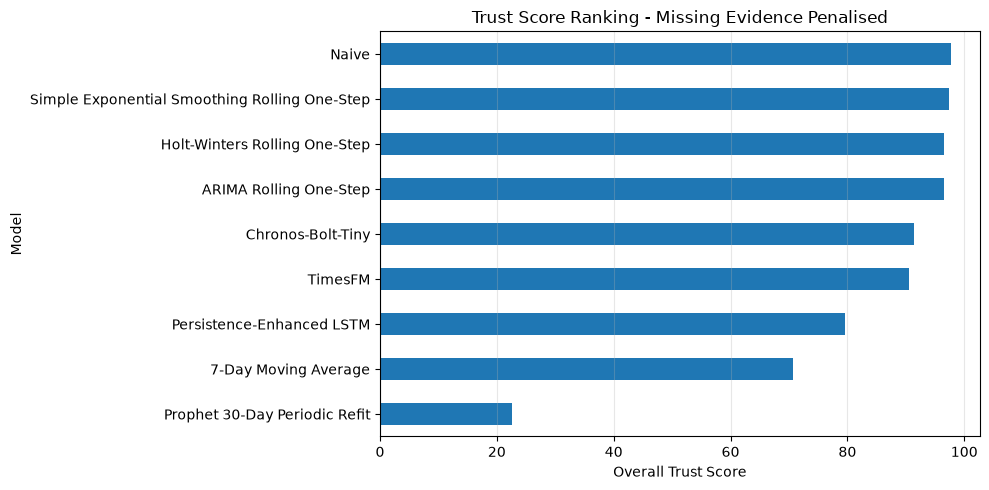

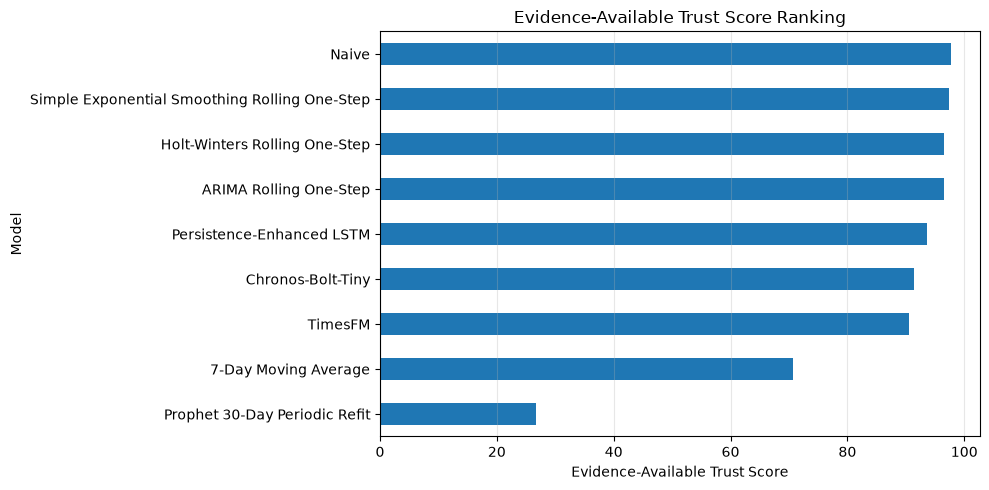

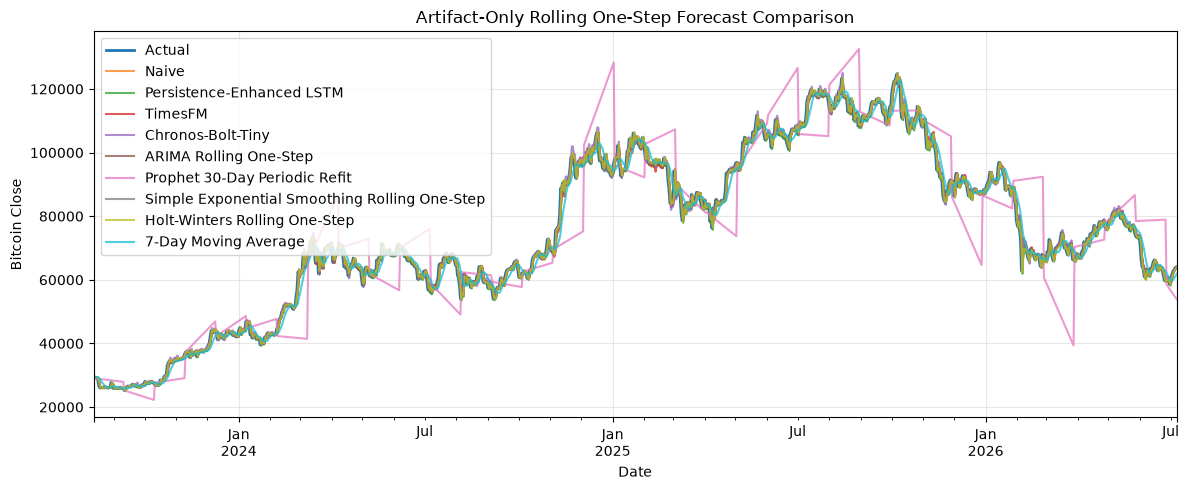

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
trust_scores["Overall Trust Score - Missing Evidence Penalised"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Trust Score Ranking - Missing Evidence Penalised")
ax.set_xlabel("Overall Trust Score")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
evidence_available_trust_scores["Evidence-Available Trust Score"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Evidence-Available Trust Score Ranking")
ax.set_xlabel("Evidence-Available Trust Score")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
y_test.plot(ax=ax, label="Actual", linewidth=2)
for model_name, forecast in forecast_series.items():
    forecast.plot(ax=ax, label=model_name, alpha=0.75)
ax.set_title("Artifact-Only Rolling One-Step Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Bitcoin Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Final Model Comparisons

The two Trust Score variants are presented separately because their independently computed ranks differ when uncertainty evidence is unavailable. Each table is sorted only by its displayed score and has its own rank column.


In [16]:
penalised_ranking = trust_scores[["Overall Trust Score - Missing Evidence Penalised"]].copy()
penalised_ranking.insert(0, "Penalised Rank", range(1, len(penalised_ranking) + 1))
evidence_available_ranking = evidence_available_trust_scores[["Evidence-Available Trust Score"]].copy()
evidence_available_ranking.insert(0, "Evidence-Available Rank", range(1, len(evidence_available_ranking) + 1))

penalised_final_comparison = metrics_table.join(penalised_ranking, how="left").sort_values("Penalised Rank")
evidence_available_final_comparison = (
    metrics_table
    .join(evidence_available_ranking, how="left")
    .join(evidence_available_trust_scores[["Unavailable Dimensions"]], how="left")
    .sort_values("Evidence-Available Rank")
)
display(penalised_final_comparison)
evidence_available_final_comparison


,MAE,RMSE,MAPE,sMAPE,MASE,N,Relative MAE,Penalised Rank,Overall Trust Score - Missing Evidence Penalised
Model,,,,,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,4.575633,1061,1.000000,1,97.803780
Simple Exponential Smoothing Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871,4.575652,1061,1.000004,2,97.466671
Holt-Winters Rolling One-Step,1308.541314,1871.702185,1.763640,1.763424,4.640128,1061,1.014095,3,96.579302
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209,4.609396,1061,1.007379,4,96.545355
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,5.049640,1061,1.103594,5,91.312313
TimesFM,1349.946786,1924.199337,1.823179,1.823895,4.786953,1061,1.046184,6,90.521931
Persistence-Enhanced LSTM,1321.365311,1881.091190,1.783956,1.791645,4.685603,1061,1.024034,7,79.600601
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,7.835935,1061,1.712536,8,70.724359
Prophet 30-Day Periodic Refit,8195.262862,10781.162873,11.199767,11.287185,29.060658,1061,6.351178,9,22.624980


,MAE,RMSE,MAPE,sMAPE,MASE,N,Relative MAE,Evidence-Available Rank,Evidence-Available Trust Score,Unavailable Dimensions
Model,,,,,,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,4.575633,1061,1.000000,1,97.803780,None
Simple Exponential Smoothing Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871,4.575652,1061,1.000004,2,97.466671,None
Holt-Winters Rolling One-Step,1308.541314,1871.702185,1.763640,1.763424,4.640128,1061,1.014095,3,96.579302,None
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209,4.609396,1061,1.007379,4,96.545355,None
Persistence-Enhanced LSTM,1321.365311,1881.091190,1.783956,1.791645,4.685603,1061,1.024034,5,93.647766,Uncertainty Score
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,5.049640,1061,1.103594,6,91.312313,None
TimesFM,1349.946786,1924.199337,1.823179,1.823895,4.786953,1061,1.046184,7,90.521931,None
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,7.835935,1061,1.712536,8,70.724359,None
Prophet 30-Day Periodic Refit,8195.262862,10781.162873,11.199767,11.287185,29.060658,1061,6.351178,9,26.617624,Uncertainty Score


## 16. Authoritative Findings

- Naive retains the best overall point accuracy and leads both Trust Score variants in the complete nine-model comparison.
- Simple Exponential Smoothing is essentially comparable to Naive and ARIMA under the fair protocol; Holt-Winters is also close, but slightly weaker.
- Prophet remains meaningfully worse than the rolling one-step statistical models.
- Persistence-Enhanced LSTM is the strongest supervised neural model with an exact saved forecast vector.
- TimesFM is the strongest zero-shot foundation model for point forecasts; Chronos is close to nominal after training-only calibration, while TimesFM remains under-covered after calibration.
- Original LSTM remains excluded because no exact validated vector exists.
- Model complexity does not guarantee trustworthiness, and different models dominate different dimensions.


## Appendix: Historical Model-Generation Workflow â€” Not Executed

Earlier versions of this notebook included model-fitting and model-inference code for ARIMA/SARIMA, raw-price LSTM, Persistence-Enhanced LSTM, Chronos, and later foundation-model comparisons. That code has been removed from the active execution path.

The historical methodology remains documented in the project notebooks that generated or audited the forecasts:
- `notebooks/05_Foundation_Models.ipynb`
- `notebooks/07_Model_Validation_Audit.ipynb`
- `notebooks/08_Naive_Forecast_Audit.ipynb`
- `notebooks/09_Statistical_Significance_Test.ipynb`

This notebook now consumes only validated forecast artifacts and deterministic baselines. It does not retrain, refit, load checkpoints, or regenerate model forecast vectors.
